In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import sys
from pathlib import Path

root = Path.cwd().resolve()

if not (root / "data").exists():
    root = root.parent

if not (root / "src").exists():
    root = root.parent

if not (root / "data").exists():
    root = root.parent

if not (root / "outputs").exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

charts_dir = root / "outputs" / "charts"
charts_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [14]:
from src.load_data import *
incidents = load_incidents()
teams = load_team_sheet()
matches = load_match_sheet()
stages = load_stage_sheet()

def save_chart(fig, filename):
    output_path = charts_dir / filename
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")

Saved: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\matches_by_bias.png


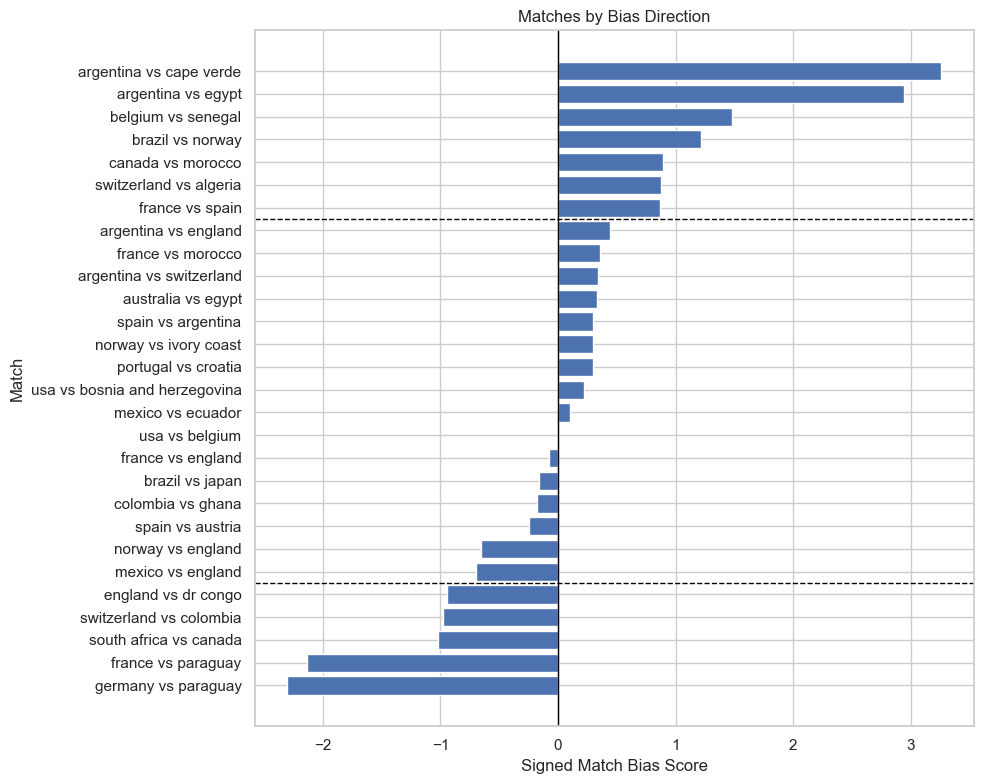

In [15]:
import numpy as np

matches_by_bias = matches.sort_values("match_bias_score")

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(matches_by_bias))

ax.barh(
    y,
    matches_by_bias["match_bias_score"]
)

ax.set_yticks(y)
ax.set_yticklabels(matches_by_bias["match_name"])

# category cutoffs based on x-values
underdog_cutoff = -0.75
favorite_cutoff = 0.75

scores = matches_by_bias["match_bias_score"].to_numpy()

# horizontal row boundaries where scores cross the x-value cutoffs
underdog_line_y = np.searchsorted(scores, underdog_cutoff, side="right") - 0.5
favorite_line_y = np.searchsorted(scores, favorite_cutoff, side="right") - 0.5

ax.axhline(underdog_line_y, color="black", linestyle="--", linewidth=1)
ax.axhline(favorite_line_y, color="black", linestyle="--", linewidth=1)

ax.axvline(0, color="black", linewidth=1)

ax.set_title("Matches by Bias Direction")
ax.set_xlabel("Signed Match Bias Score")
ax.set_ylabel("Match")

save_chart(fig, "matches_by_bias.png")
plt.show()

Saved: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\matches_by_impact.png


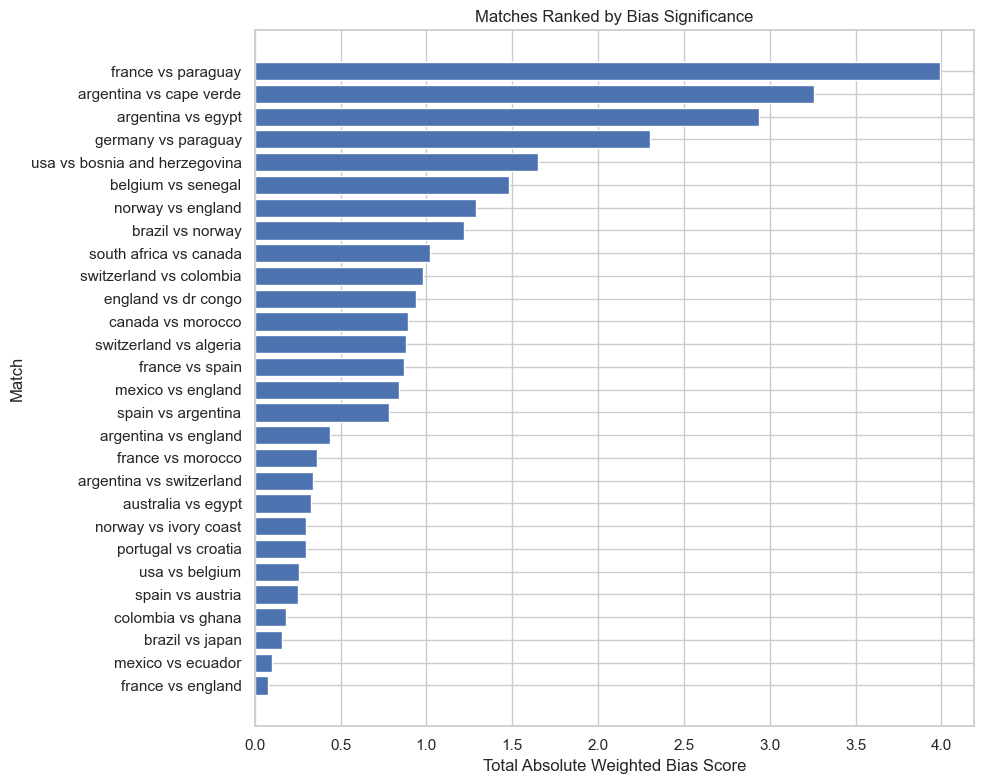

In [16]:
plot_df = matches.sort_values("abs_bias_significance")

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(plot_df["match_name"], plot_df["abs_bias_significance"])

ax.set_title("Matches Ranked by Bias Significance")
ax.set_xlabel("Total Absolute Weighted Bias Score")
ax.set_ylabel("Match")

save_chart(fig, "matches_by_impact.png")
plt.show()

Saved: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\total_benefit.png


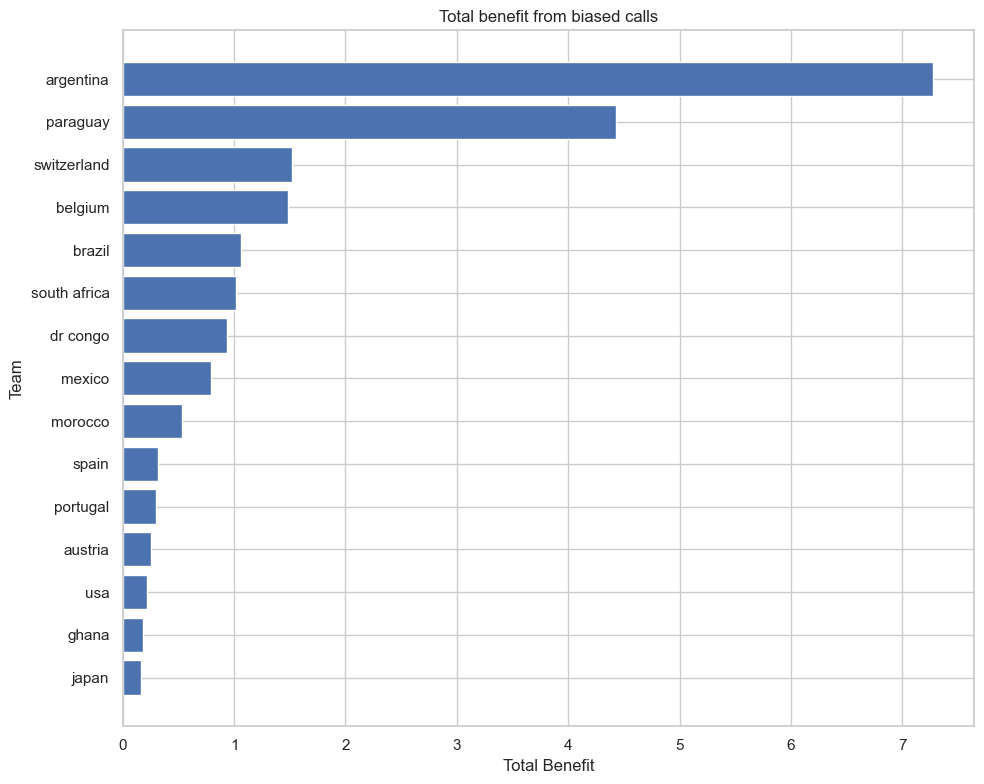

In [17]:
plot_df = teams[teams["impact"] >= 0]
plot_df = plot_df.sort_values("impact")
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(plot_df["team"], plot_df["impact"])
ax.set_title("Total benefit from biased calls")
ax.set_xlabel("Total Benefit")
ax.set_ylabel("Team")

save_chart(fig, "total_benefit.png")
plt.show()

Saved: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\total_harm.png


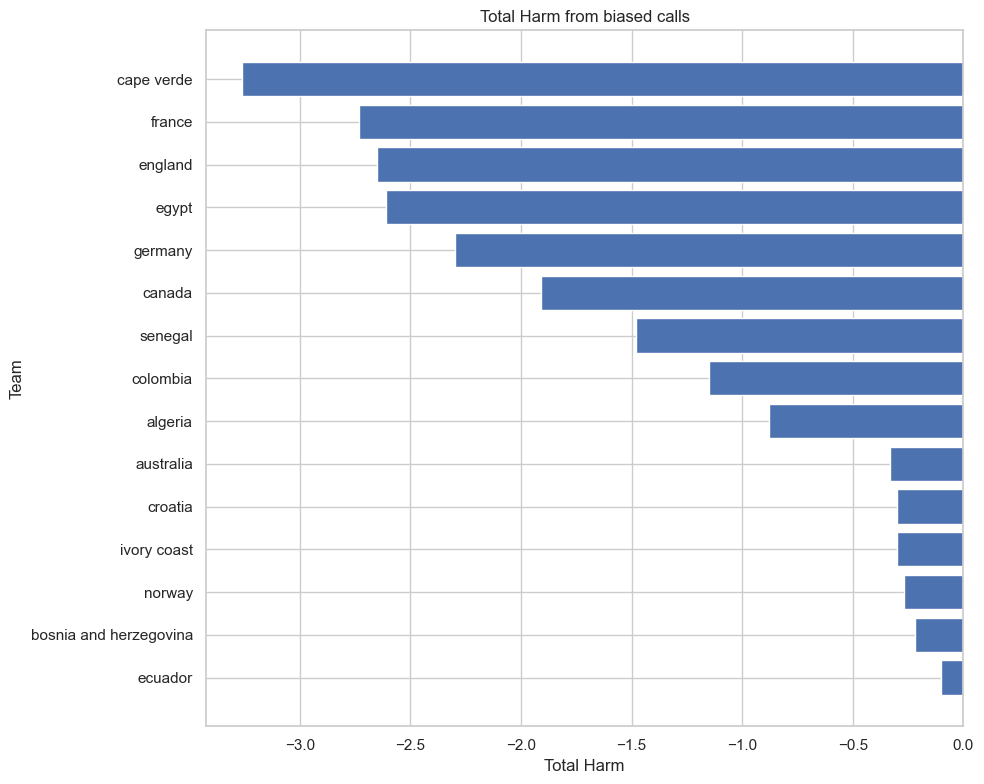

In [18]:
plot_df = teams[teams["impact"] < 0]
plot_df = plot_df.sort_values("impact", ascending = False)
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(plot_df["team"], plot_df["impact"])
ax.set_title("Total Harm from biased calls")
ax.set_xlabel("Total Harm")
ax.set_ylabel("Team")

save_chart(fig, "total_harm.png")
plt.show()

Saved: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\impact_per_match.png


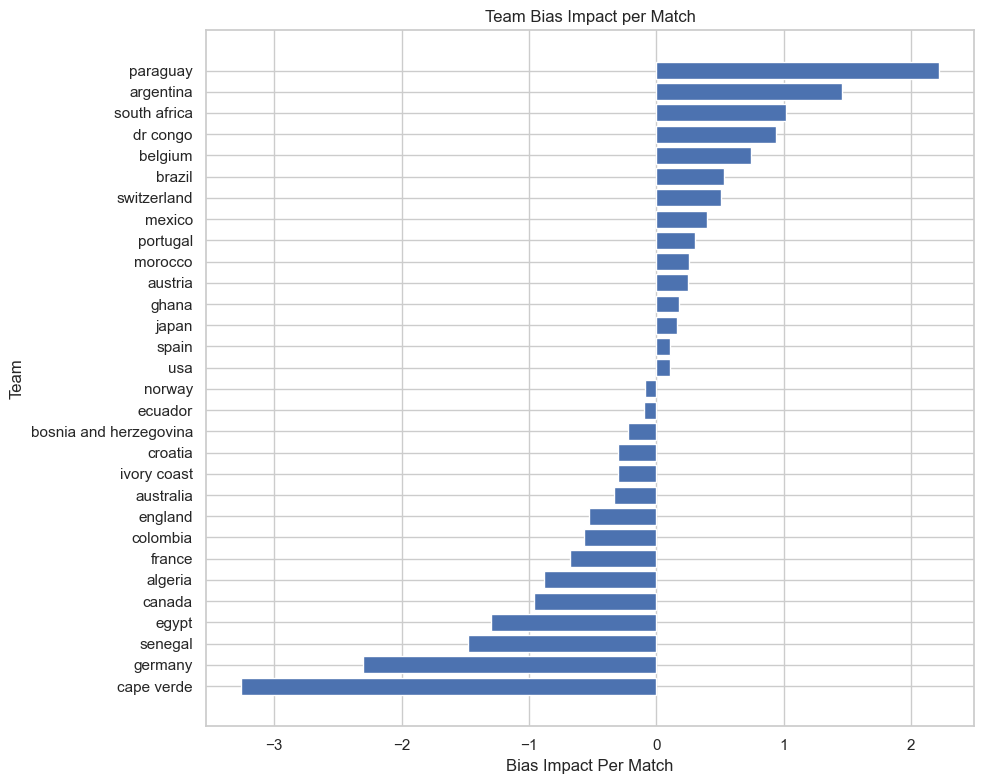

In [19]:
plot_df = teams.sort_values("impact_per_match")

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(plot_df["team"], plot_df["impact_per_match"])
ax.set_title("Team Bias Impact per Match")
ax.set_xlabel("Bias Impact Per Match")
ax.set_ylabel("Team")

save_chart(fig, "impact_per_match.png")
plt.show()


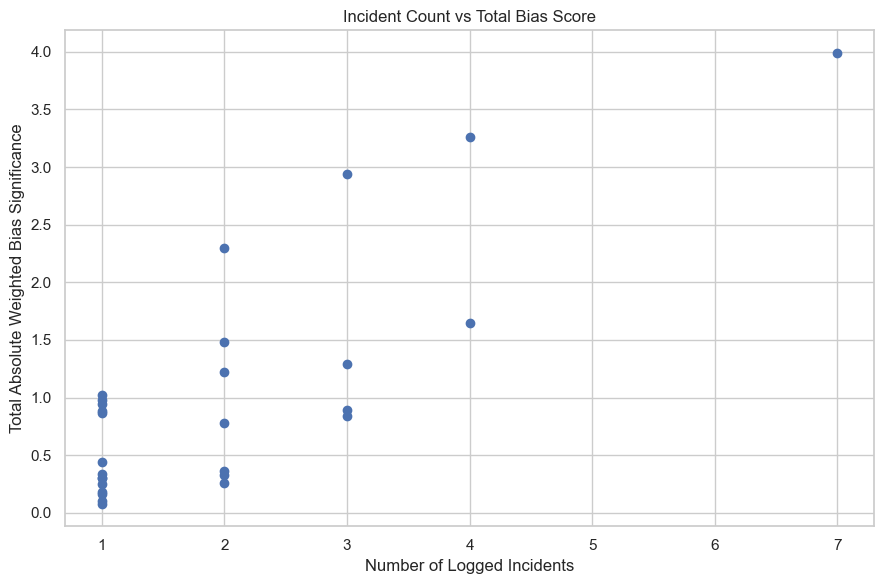

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(matches["incident_count"], matches["abs_bias_significance"])



ax.set_title("Incident Count vs Total Bias Score")
ax.set_xlabel("Number of Logged Incidents")
ax.set_ylabel("Total Absolute Weighted Bias Significance")

fig.tight_layout()
fig.savefig(
    charts_dir / "incident_count_vs_impact.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

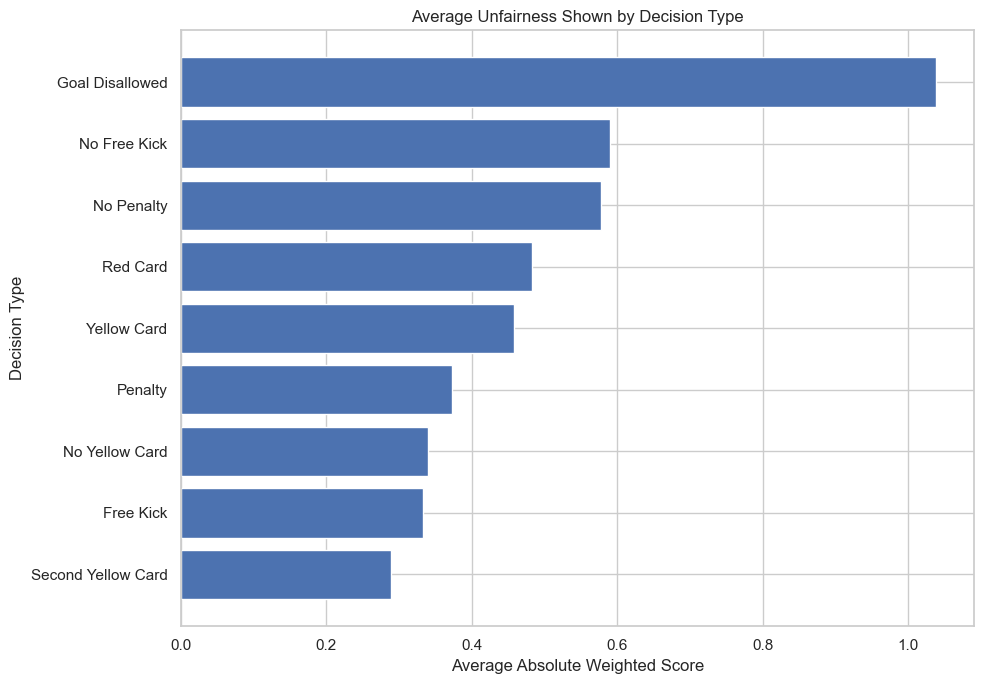

In [21]:
df = incidents[incidents["incident_type"] != "Game Management"]
incident_type_summary = (
    df.groupby("decision")
    .agg(
        incident_count=("incident_id", "count"),
        total_impact=("abs_bias_significance", "sum"),
        average_impact=("abs_bias_significance", "mean")
    )
    .reset_index()
)

plot_df = incident_type_summary.sort_values("average_impact")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(plot_df["decision"], plot_df["average_impact"])

ax.set_title("Average Unfairness Shown by Decision Type")
ax.set_xlabel("Average Absolute Weighted Score")
ax.set_ylabel("Decision Type")

fig.tight_layout()
fig.savefig(
    charts_dir / "impact_by_incident_type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Saved: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\match_score_vs_spread.png


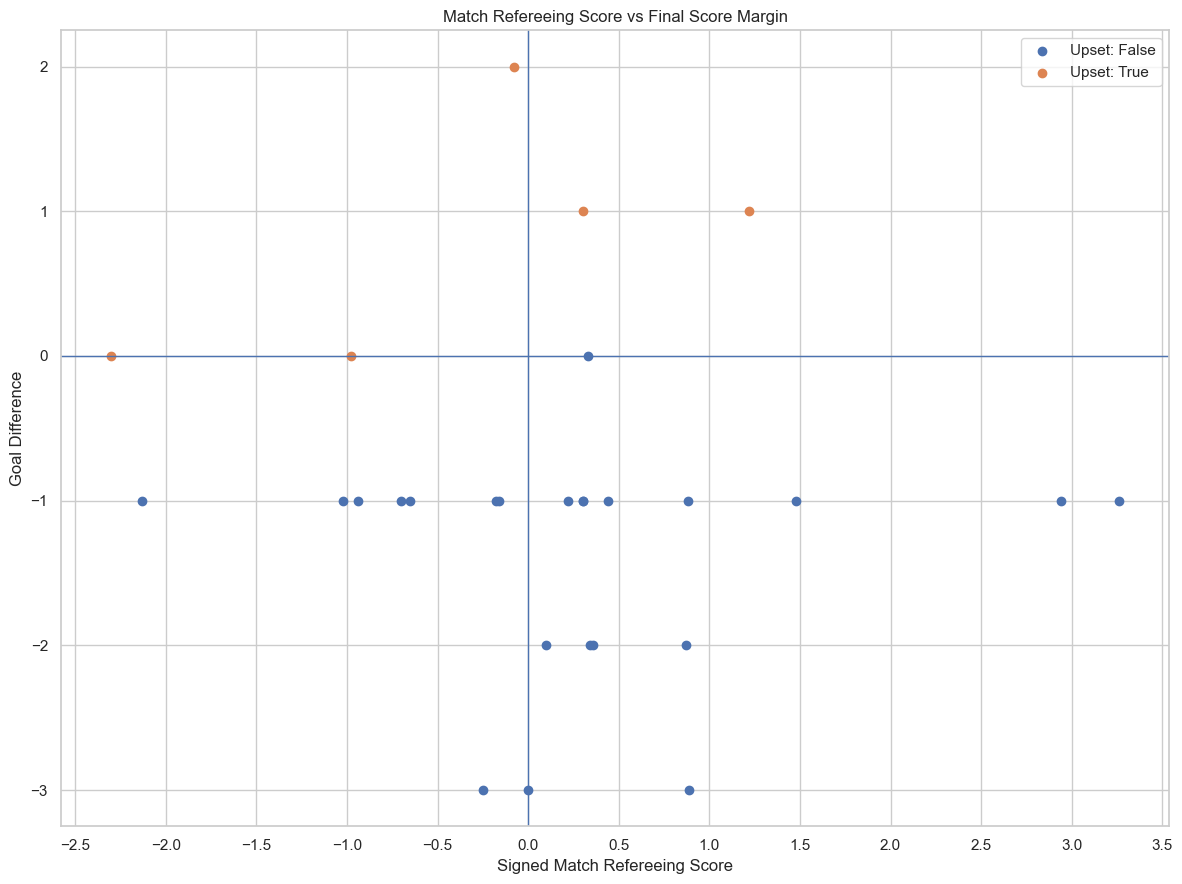

In [22]:
fig, ax = plt.subplots(figsize=(12, 9))

for upset_value, group in matches.groupby("upset"):
    ax.scatter(
        group["match_bias_score"],
        group["spread"],
        label=f"Upset: {upset_value}"
    )

ax.axvline(0, linewidth=1)
ax.axhline(0, linewidth=1)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(1))

ax.set_title("Match Refereeing Score vs Final Score Margin")
ax.set_xlabel("Signed Match Refereeing Score")
ax.set_ylabel("Goal Difference")
ax.legend()

save_chart(fig, "match_score_vs_spread.png")
plt.show()

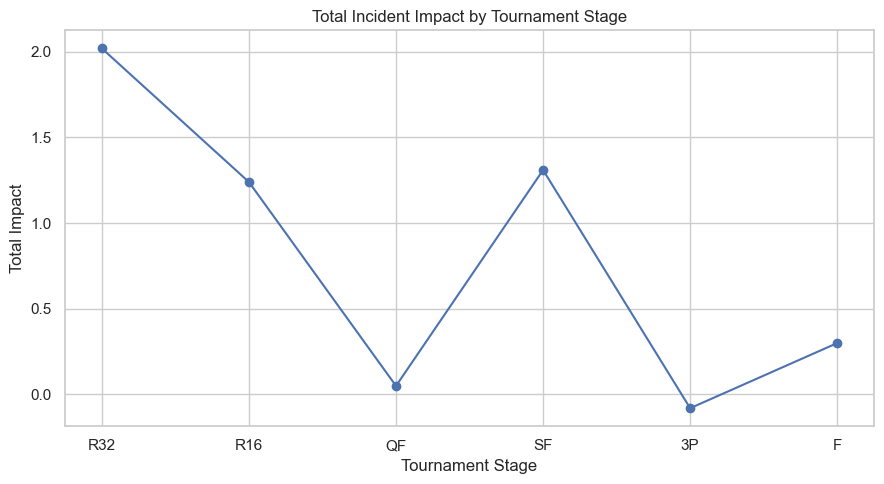

In [23]:
stage_order = ["R32", "R16", "QF", "SF", "3P", "F"]

stages["stage"] = pd.Categorical(
    stages["stage"],
    categories=stage_order,
    ordered=True
)

plot_df = stages.sort_values("stage")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    plot_df["stage"],
    plot_df["total_match_bias_score"],
    marker="o"
)

ax.set_title("Total Incident Impact by Tournament Stage")
ax.set_xlabel("Tournament Stage")
ax.set_ylabel("Total Impact")

fig.tight_layout()
fig.savefig(charts_dir / "impact_by_stage.png", dpi=300, bbox_inches="tight")
plt.show()